In [81]:
# %cd backend/
# !pwd

In [99]:
import importlib

import segmentacao.carregar
importlib.reload(segmentacao.carregar)

import segmentacao.contorno_ativo
importlib.reload(segmentacao.contorno_ativo)

from segmentacao.carregar import carregar_imagem
from segmentacao.contorno_ativo import MCACrisp
from PIL import Image, ImageDraw
import numpy as np
import cv2
import logging

logging.basicConfig(level=logging.DEBUG)

img = "./data/pulmao2/100.dcm"

mca = MCACrisp(
    img,
    180,
    360,
    256,
    512,
    quantidade_pixels=60,
    raio=60,
    w_cont=0.6,
    w_adapt=0.3,
    area_de_busca=9,
    d_max=6,
    alpha=20,
    early_stop=0.01
)


def create_gif(curves, image_path, output_gif_path, output_image_path=None, duration=100):
    """
    Create a GIF from a list of curves overlaid on the original image.

    Args:
        curves (list): List of curves (each curve is a numpy array of points).
        image_path (str): Path to the original image.
        output_gif_path (str): Path to save the output GIF.
        duration (int): Duration (in milliseconds) for each frame in the GIF.
    """
    # Load the original image
    img = carregar_imagem(image_path)
    img = (img - img.min()) / (img.max() - img.min()) * 255
    img = img.astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img = Image.fromarray(img)
    width, height = img.size

    print("Creating gif...")
    frames = []
    for curve in curves:
        frame = img.copy()
        draw = ImageDraw.Draw(frame)

        # Draw the curve on the frame
        if len(curve) > 0:
            points = [(point[0], point[1]) for point in curve]
            draw.line(points, fill="red", width=2)

        frames.append(frame)

    frames[0].save(
        output_gif_path,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
    )

    print(f'Git created on {output_gif_path}')

    if output_image_path:
        last_frame = frames[-1]  # Get the last frame
        last_frame.save(output_image_path, "JPEG")


curves = []
for curva in mca.process(max_iterations=1000):
    curves.append(curva)

# Create a GIF from the collected curves
output_gif_path = "output.gif"
create_gif(curves, img, output_gif_path, output_image_path='output.jpg', duration=100)


INFO:segmentacao.contorno_ativo:Starting segmentation process
DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=23)
           2	RESUME(arg=0, lineno=23)
           4	LOAD_GLOBAL(arg=1, lineno=25)
          14	LOAD_ATTR(arg=2, lineno=25)
          34	LOAD_FAST(arg=0, lineno=25)
          36	CALL(arg=1, lineno=25)
          44	STORE_FAST(arg=5, lineno=25)
          46	LOAD_GLOBAL(arg=5, lineno=26)
          56	LOAD_ATTR(arg=6, lineno=26)
          76	LOAD_GLOBAL(arg=9, lineno=26)
          86	LOAD_FAST(arg=5, lineno=26)
          88	CALL(arg=1, lineno=26)
          96	CALL(arg=1, lineno=26)
         104	GET_ITER(arg=None, lineno=26)
>        106	FOR_ITER(arg=22, lineno=26)
         110	STORE_FAST(arg=6, lineno=26)
         112	LOAD_GLOBAL(arg=11, lineno=27)
         122	LOAD_FAST(arg=5, lineno=28)
         124	LOAD_FAST(arg=6, lineno=29)
         126	LOAD_FAST(arg=1, lineno=30)
         128	LOAD_FAST(arg=2, lineno=31)
         130	LOAD_FAST(arg=3, lineno=32)
   

DEBUG:numba.core.byteflow:dispatch pc=44, inst=STORE_FAST(arg=5, lineno=25)
DEBUG:numba.core.byteflow:stack ['$36call.4']
DEBUG:numba.core.byteflow:dispatch pc=46, inst=LOAD_GLOBAL(arg=5, lineno=26)
DEBUG:numba.core.byteflow:stack []
DEBUG:numba.core.byteflow:dispatch pc=56, inst=LOAD_ATTR(arg=6, lineno=26)
DEBUG:numba.core.byteflow:stack ['$null$46.6', '$46load_global.5']
DEBUG:numba.core.byteflow:dispatch pc=76, inst=LOAD_GLOBAL(arg=9, lineno=26)
DEBUG:numba.core.byteflow:stack ['$null$46.6', '$56load_attr.7']
DEBUG:numba.core.byteflow:dispatch pc=86, inst=LOAD_FAST(arg=5, lineno=26)
DEBUG:numba.core.byteflow:stack ['$null$46.6', '$56load_attr.7', '$null$76.9', '$76load_global.8']
DEBUG:numba.core.byteflow:dispatch pc=88, inst=CALL(arg=1, lineno=26)
DEBUG:numba.core.byteflow:stack ['$null$46.6', '$56load_attr.7', '$null$76.9', '$76load_global.8', '$nova_curva86.10']
DEBUG:numba.core.byteflow:dispatch pc=96, inst=CALL(arg=1, lineno=26)
DEBUG:numba.core.byteflow:stack ['$null$46.6', '$

Creating gif...
Git created on output.gif


Text(0.5, 0.98, 'só remoção antiga alpha=20')

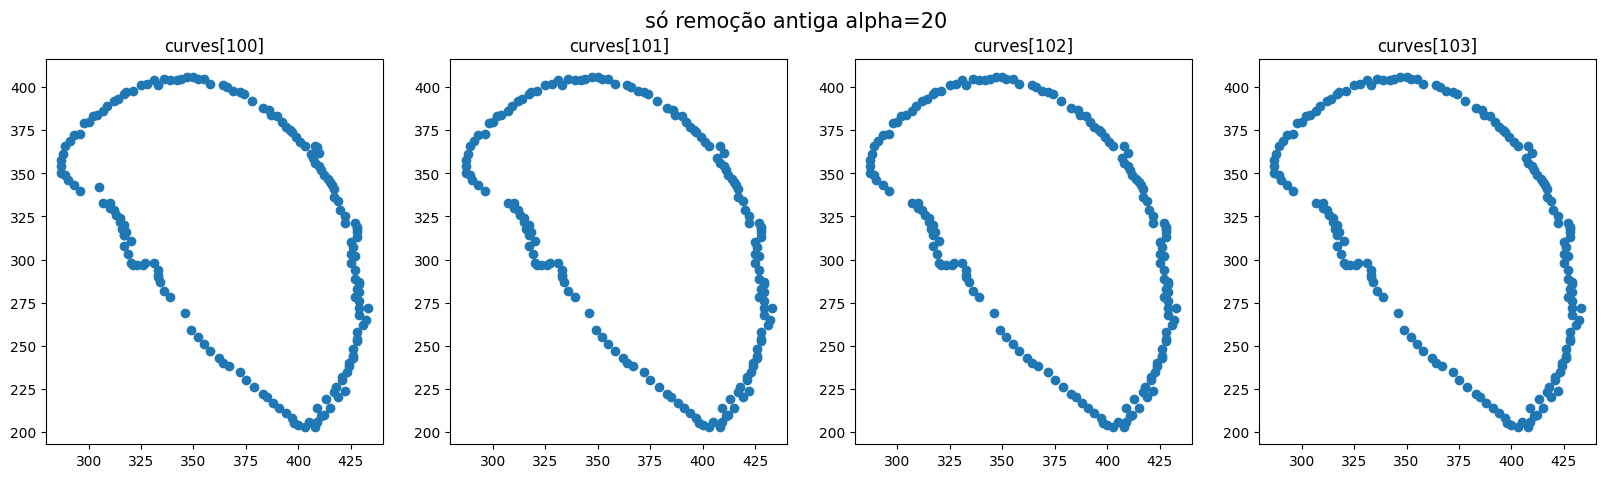

In [84]:
import importlib
import segmentacao.curva
importlib.reload(segmentacao.curva)

from segmentacao.curva import remover_pontos

start=100

curvas_teste = []
curvas_teste.append(curves[start])

fig, ax = plt.subplots(1, 4, figsize=(20,5))
ax.flatten()

alpha=20

for i in range(4):
    curvas_teste.append(remover_pontos(curvas_teste[-1], alpha=alpha))
    ax[i].scatter(curvas_teste[i][:, 0], curvas_teste[i][:, 1])
    ax[i].set_title(f'curves[{start+i}]')

fig.suptitle(f'só remoção antiga {alpha=}', fontsize=15)

In [85]:
import importlib
import segmentacao.curva1
importlib.reload(segmentacao.curva1)

from segmentacao.curva1 import remover_pontos as remover_pontos1

start=700

curvas_teste = []
curvas_teste.append(curves[start])

fig, ax = plt.subplots(1, 4, figsize=(20,5))
ax.flatten()

alpha = 20

for i in range(4):
    curva = remover_pontos1(curvas_teste[-1], alpha=alpha)
    curvas_teste.append(curva)
    ax[i].scatter(curvas_teste[i][:, 0], curvas_teste[i][:, 1])
    ax[i].set_title(f'curves[{start+i}]')

fig.suptitle(f'só remoção nova {alpha=}', fontsize=15)

IndexError: list index out of range

In [6]:
curves[100]

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [7]:
import importlib
import segmentacao.curva1
importlib.reload(segmentacao.curva1)

from segmentacao.curva1 import remover_pontos as remover_pontos1
from segmentacao.curva1 import adicionar_pontos as adicionar_pontos1
from segmentacao.carregar import carregar_imagem


curvaadd = adicionar_pontos1(curves[100], carregar_imagem(img), 10)
curvarem = remover_pontos1(curves[100], alpha=0)

DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=156)
           2	RESUME(arg=0, lineno=156)
           4	LOAD_FAST(arg=0, lineno=169)
           6	UNPACK_SEQUENCE(arg=2, lineno=169)
          10	STORE_FAST(arg=2, lineno=169)
          12	STORE_FAST(arg=3, lineno=169)
          14	LOAD_FAST(arg=1, lineno=170)
          16	LOAD_ATTR(arg=0, lineno=170)
          36	LOAD_CONST(arg=1, lineno=170)
          38	BINARY_SUBSCR(arg=None, lineno=170)
          42	STORE_FAST(arg=4, lineno=170)
          44	LOAD_CONST(arg=2, lineno=171)
          46	STORE_FAST(arg=5, lineno=171)
          48	LOAD_GLOBAL(arg=3, lineno=173)
          58	LOAD_FAST(arg=4, lineno=173)
          60	CALL(arg=1, lineno=173)
          68	GET_ITER(arg=None, lineno=173)
>         70	FOR_ITER(arg=63, lineno=173)
          74	STORE_FAST(arg=6, lineno=173)
          76	LOAD_FAST(arg=1, lineno=174)
          78	LOAD_FAST(arg=6, lineno=174)
          80	BINARY_SUBSCR(arg=None, lineno=174)
          84	UN

In [8]:
curves[100].shape

(139, 2)

In [9]:
curvaadd.shape

(145, 2)

In [10]:
curvarem.shape

(131, 2)

DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=156)
           2	RESUME(arg=0, lineno=156)
           4	LOAD_FAST(arg=0, lineno=169)
           6	UNPACK_SEQUENCE(arg=2, lineno=169)
          10	STORE_FAST(arg=2, lineno=169)
          12	STORE_FAST(arg=3, lineno=169)
          14	LOAD_FAST(arg=1, lineno=170)
          16	LOAD_ATTR(arg=0, lineno=170)
          36	LOAD_CONST(arg=1, lineno=170)
          38	BINARY_SUBSCR(arg=None, lineno=170)
          42	STORE_FAST(arg=4, lineno=170)
          44	LOAD_CONST(arg=2, lineno=171)
          46	STORE_FAST(arg=5, lineno=171)
          48	LOAD_GLOBAL(arg=3, lineno=173)
          58	LOAD_FAST(arg=4, lineno=173)
          60	CALL(arg=1, lineno=173)
          68	GET_ITER(arg=None, lineno=173)
>         70	FOR_ITER(arg=63, lineno=173)
          74	STORE_FAST(arg=6, lineno=173)
          76	LOAD_FAST(arg=1, lineno=174)
          78	LOAD_FAST(arg=6, lineno=174)
          80	BINARY_SUBSCR(arg=None, lineno=174)
          84	UN

Text(0.5, 0.98, 'remoção e adição nova alpha=20')

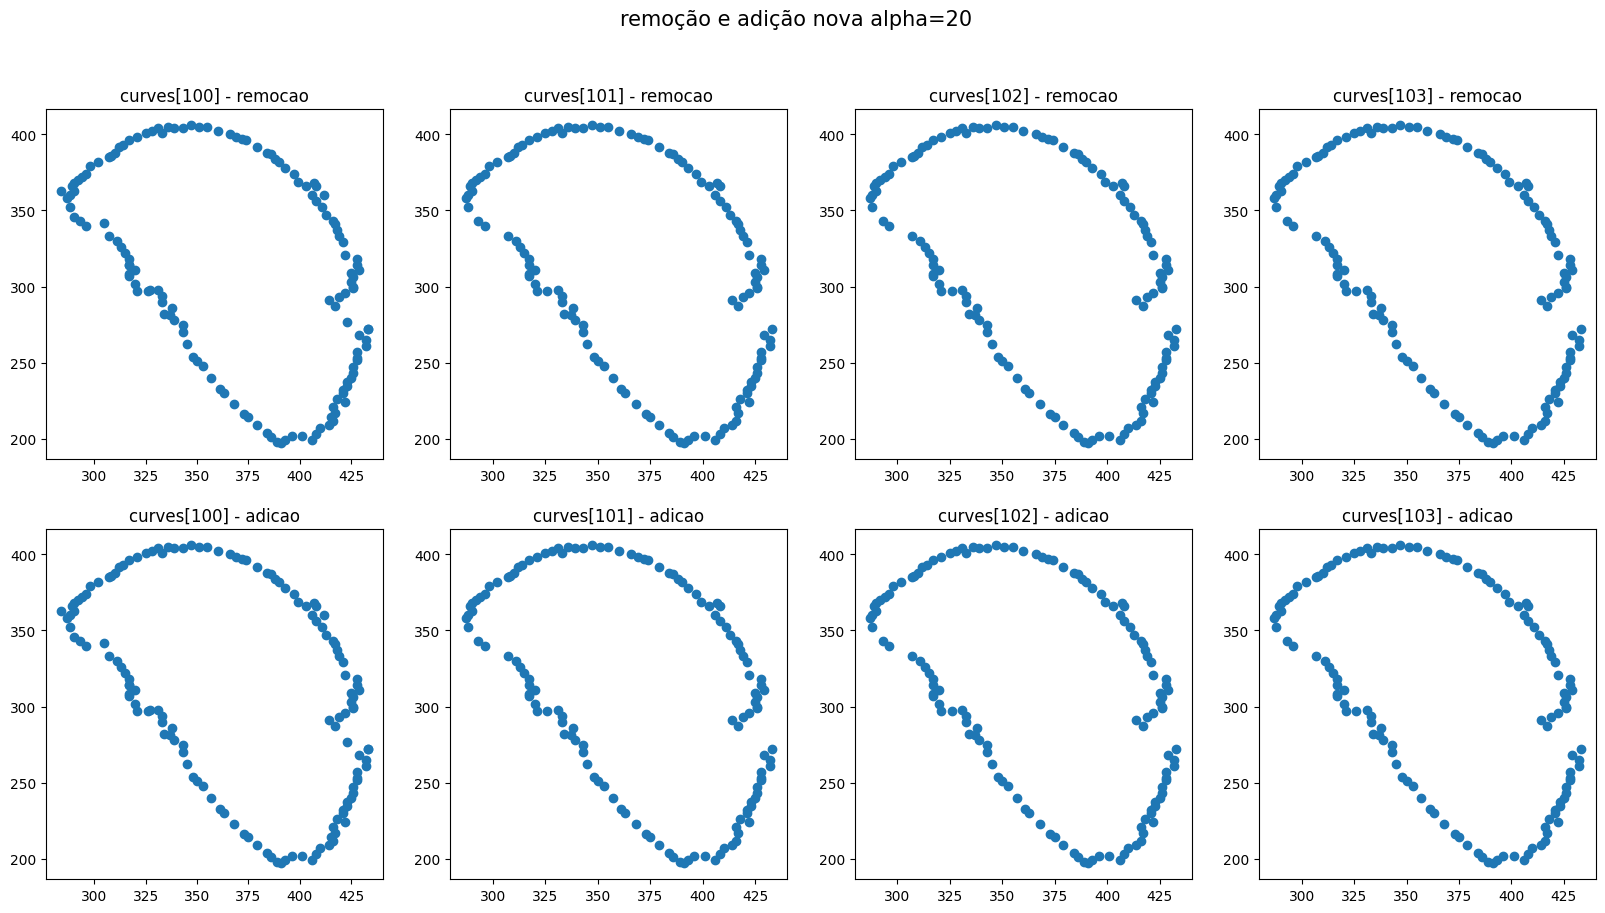

In [11]:
import importlib
import segmentacao.curva1
importlib.reload(segmentacao.curva1)

from segmentacao.curva1 import remover_pontos as remover_pontos1
from segmentacao.curva1 import adicionar_pontos as adicionar_pontos1

start=100

curvas_teste = []
curvas_teste.append(curves[start])

fig, ax = plt.subplots(2, 4, figsize=(20,10))
ax = ax.flatten()

alpha = 20

qtd=4

for i in range(qtd):
    curva_remocao = remover_pontos1(curvas_teste[-1], alpha=alpha)
    curvas_teste.append(curva_remocao)
    ax[i].scatter(curvas_teste[i][:, 0], curvas_teste[i][:, 1])
    ax[i].set_title(f'curves[{start+i}] - remocao')
    curva_adicao = adicionar_pontos1(curvas_teste[-2], imagem=carregar_imagem(img), d_max=10)
    ax[i+qtd].scatter(curvas_teste[i][:, 0], curvas_teste[i][:, 1])
    ax[i+qtd].set_title(f'curves[{start+i}] - adicao')

fig.suptitle(f'remoção e adição nova {alpha=}', fontsize=15)

In [12]:
curves[100]

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [13]:
curves[101]

array([[317, 308],
       [319, 303],
       [320, 298],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [343, 266],
       [346, 258],
       [350, 251],
       [354, 243],
       [359, 236],
       [361, 233],
       [365, 226],
       [370, 219],
       [373, 216],
       [379, 211],
       [383, 205],
       [384, 204],
       [387, 200],
       [391, 197],
       [395, 199],
       [400, 201],
       [402, 203],
       [405, 206],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 233],
       [423, 236],
       [424, 239],
       [425, 241],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428, 257],
       [432,

In [14]:
curva = curves[100]
curva

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [15]:
curves[100]

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [16]:
curva1 = remover_pontos(curves[100], 20)
curva1

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [17]:
np.unique(curves[100], axis=0)

array([[284, 363],
       [287, 358],
       [288, 352],
       [288, 360],
       [289, 366],
       [290, 346],
       [290, 363],
       [290, 368],
       [292, 370],
       [293, 343],
       [294, 372],
       [296, 340],
       [296, 374],
       [298, 379],
       [302, 382],
       [305, 342],
       [307, 333],
       [307, 385],
       [308, 386],
       [310, 388],
       [311, 330],
       [312, 392],
       [313, 326],
       [314, 393],
       [315, 322],
       [317, 307],
       [317, 308],
       [317, 314],
       [317, 318],
       [317, 396],
       [320, 302],
       [320, 311],
       [321, 297],
       [321, 398],
       [325, 401],
       [326, 297],
       [327, 298],
       [328, 402],
       [331, 298],
       [331, 404],
       [333, 290],
       [333, 294],
       [333, 401],
       [334, 282],
       [336, 405],
       [337, 281],
       [338, 286],
       [339, 278],
       [339, 404],
       [343, 270],
       [343, 275],
       [343, 404],
       [345,

In [18]:
curves[100]

array([[317, 308],
       [317, 307],
       [320, 302],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [345, 262],
       [348, 254],
       [350, 251],
       [353, 248],
       [357, 240],
       [361, 233],
       [363, 230],
       [368, 223],
       [373, 216],
       [375, 214],
       [379, 209],
       [384, 204],
       [386, 201],
       [389, 198],
       [391, 197],
       [393, 199],
       [396, 202],
       [401, 202],
       [406, 199],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 232],
       [423, 235],
       [423, 237],
       [425, 240],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428,

In [19]:
curves[101]

array([[317, 308],
       [319, 303],
       [320, 298],
       [321, 297],
       [327, 298],
       [326, 297],
       [331, 298],
       [333, 294],
       [333, 290],
       [338, 286],
       [334, 282],
       [337, 281],
       [339, 278],
       [343, 275],
       [343, 270],
       [343, 266],
       [346, 258],
       [350, 251],
       [354, 243],
       [359, 236],
       [361, 233],
       [365, 226],
       [370, 219],
       [373, 216],
       [379, 211],
       [383, 205],
       [384, 204],
       [387, 200],
       [391, 197],
       [395, 199],
       [400, 201],
       [402, 203],
       [405, 206],
       [408, 203],
       [410, 207],
       [414, 209],
       [415, 214],
       [416, 212],
       [417, 217],
       [416, 221],
       [418, 226],
       [422, 224],
       [421, 230],
       [421, 233],
       [423, 236],
       [424, 239],
       [425, 241],
       [426, 243],
       [426, 247],
       [428, 252],
       [428, 253],
       [428, 257],
       [432,